In [2]:
import torch
from torch import nn

x = torch.tensor([1.])
model = nn.Linear(1,1) # 입력노드 1개, 출력노드 1개인 layer만듬
print(model)

print(model.weight) # 위에서 레이어 만들면서 자동으로 가중치와 바이어스 initialize되며 생성된다
print(model.bias) # 가중치와 편향은 미분가능변수이니 grad True값으로 출력됨
# 파이토치 내부에서 신경망 저렇게 만들어놓으면 아래 y2와 같이 가중치 곱하고 바이어스더해서 출력하도록 설계되어있다.
y = model(x)
print(y)

Linear(in_features=1, out_features=1, bias=True)
Parameter containing:
tensor([[-0.8791]], requires_grad=True)
Parameter containing:
tensor([-0.4953], requires_grad=True)
tensor([-1.3743], grad_fn=<ViewBackward0>)


In [7]:
# nn.Linear 모델의 연산(내부구조 확인)

y2 = x @ model.weight + model.bias
print(y2) # 위 nn.Linear연산과 비교해보면 결과가 같음을 알수있다

tensor([-1.3743], grad_fn=<AddBackward0>)


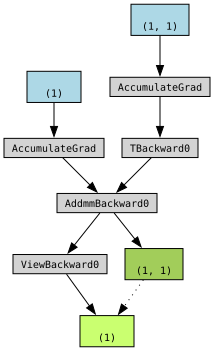

In [6]:
import os

os.environ["PATH"] += os.pathsep + "/opt/anaconda3/envs/brain_env1/bin"
  # 여기엔 which dot 결과 경로 입력

from torchviz import make_dot

make_dot(y)

In [10]:
fc1 = nn.Linear(1,3) # fully-connected
fc2 = nn.Linear(3,1)

print(fc1.weight)
print(fc1.bias) # 세개의 신경 각각의 민감도 조정해주는 bias 세개
print(fc2.weight)
print(fc2.bias) # 여기는 bias 한개

Parameter containing:
tensor([[-0.4087],
        [-0.7253],
        [-0.6715]], requires_grad=True)
Parameter containing:
tensor([-0.2507,  0.5600, -0.8050], requires_grad=True)
Parameter containing:
tensor([[ 0.3537, -0.0636, -0.0078]], requires_grad=True)
Parameter containing:
tensor([-0.4560], requires_grad=True)


In [11]:
#위 두개의 신경망 합쳐서 입력값 한개가 세개의 은닉층으로가서 한개의 출력값으로 나온다.
x = torch.tensor([1.])
x = fc1(x)
print(x)
y = fc2(x)
print(y)

tensor([-0.6593, -0.1653, -1.4765], grad_fn=<ViewBackward0>)
tensor([-0.6672], grad_fn=<ViewBackward0>)


tensor([-0.6672], grad_fn=<AddBackward0>)


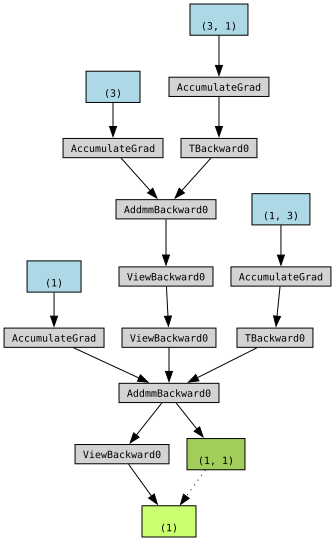

In [12]:
x = torch.tensor([1.])
y2 = (x @ fc1.weight.T + fc1.bias) @ fc2.weight.T + fc2.bias
print(y2)

make_dot(y)

tensor([-0.4341, -0.6100])
tensor([ 0.2366,  0.0932, -0.9733], grad_fn=<ViewBackward0>)


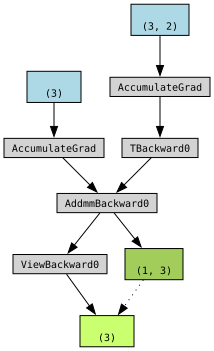

In [15]:
model = nn.Linear(2,3) # 입력노드 하나 = 채널(feature)
x = torch.randn(2)
print(x)
print(model(x))

make_dot(model(x))
"""
nn.Linear 는 1D(1차원)으로 입력값이 들어오길 기대한다.
"""

In [16]:
model = nn.Linear(2,3)

x = torch.randn(5,2) # 두개의 특징(키, 몸무게)를 가지는 5개의 데이터(5명) => 5행 2열 (샘플 5개)

print(x)
print(model(x))

x = torch.randn(4,5,2) # 5명의 사람이 4개의 조라고 생각하자
print(model(x).shape)

tensor([[ 1.9353, -0.4422],
        [-0.6993, -1.2816],
        [-0.4519,  1.3012],
        [ 0.7205,  0.6899],
        [-0.8330,  1.5606]])
tensor([[ 0.1749,  0.0662, -1.2947],
        [-0.8058,  0.1334,  0.6177],
        [-0.3305, -1.0914, -0.6232],
        [-0.0448, -0.6421, -1.0568],
        [-0.4141, -1.2670, -0.5080]], grad_fn=<AddmmBackward0>)
torch.Size([4, 5, 3])


torch.Size([2, 3, 6, 4, 5, 3])


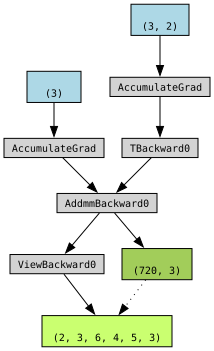

In [20]:
x = torch.randn(2,3,6,4,5,2) # 비유 2개의 학교 3개의 학년 6개의 반 4개의 조 5명의 사람의 2개의 특징
print(model(x).shape)
make_dot(model(x))

tensor([ 0.2397,  0.1392, -1.0573], grad_fn=<ViewBackward0>)
tensor([0.7022], grad_fn=<ViewBackward0>)
tensor([0.7022], grad_fn=<ViewBackward0>)


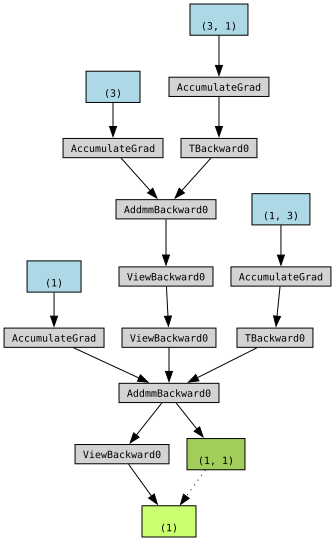

In [22]:
# layer 붙이기 Sequential함수

fc1 = nn.Linear(1,3)
fc2 = nn.Linear(3,1)

x = torch.tensor([1.])
x = fc1(x)
print(x)
x = fc2(x)
print(x)

model = nn.Sequential(fc1,fc2) # 위에 출력을 다음신경망에 수동으로 넣는 코드와 결과가 일치함을 확인할수있다
x = torch.tensor([1.])
print(model(x))

make_dot(model(x))

In [23]:
model = nn.Sequential(nn.Linear(2,5),
                      nn.Linear(5,10),
                      nn.Linear(10,3)) # 이 코드만 보고 모델의 이미지가 그려진다 (feature의 개수는 각각 맞아야함) 세개의 층인 신경망

x = torch.randn(5,2)
print(x)
print(model(x))

tensor([[ 2.3835, -0.0359],
        [ 0.7820, -1.9149],
        [-1.1467, -0.6023],
        [-0.1359, -0.7673],
        [-1.1649, -0.9258]])
tensor([[-0.1493, -0.2246, -0.3104],
        [-0.0740, -0.0592, -0.1014],
        [-0.1547, -0.3163,  0.7431],
        [-0.1375, -0.2483,  0.3872],
        [-0.1393, -0.2759,  0.6954]], grad_fn=<AddmmBackward0>)


In [31]:
# 보통 클래스를 이용해 모델을 잘 선언한다

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2,5)
        self.fc2 = nn.Linear(5,10)
        self.fc3 = nn.Linear(10,3)
        self.act = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        x = self.act(x)
        return x

model = MyModel()
x = torch.randn(5,2)
y = model(x) # model.forward(x)와 동일 (nn.Module의 __call__이라는 스페셜모듈 이요해서 forward 통과시킴)
print(y)

"""
init과 foward는 반드시 필요함
forward는 위에서 만들어놓은 신경망들을 어떻게 구성해 통과시킬것인지 결정한다.
"""

tensor([[0.4918, 0.4169, 0.4863],
        [0.4943, 0.4145, 0.4858],
        [0.4960, 0.4233, 0.4864],
        [0.4944, 0.4188, 0.4862],
        [0.4967, 0.4237, 0.4863]], grad_fn=<SigmoidBackward0>)


'\ninit과 foward는 반드시 필요함\nforward는 위에서 만들어놓은 신경망들을 어떻게 구성해 통과시킬것인지 결정한다.\n'

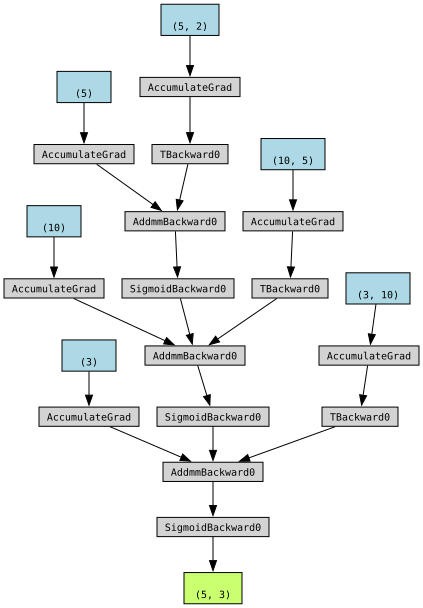

In [32]:
make_dot(y) # leaf tensor 개념 이해

In [33]:
print(model)
print(model.fc1.weight)
print(model.fc2.bias) # 위 모델의 각층에 접근해서 원하는 정보(가중치,편향 등)를 열람할수있다

MyModel(
  (fc1): Linear(in_features=2, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=3, bias=True)
  (act): Sigmoid()
)
Parameter containing:
tensor([[ 0.2335,  0.4578],
        [ 0.2711,  0.2186],
        [-0.1652, -0.5588],
        [ 0.4343, -0.0378],
        [ 0.0680, -0.7019]], requires_grad=True)
Parameter containing:
tensor([ 0.1063,  0.2837,  0.2924,  0.0880,  0.2967,  0.1195,  0.4428, -0.3672,
        -0.4395,  0.3464], requires_grad=True)


tensor([[0.4297, 0.6355, 0.6155],
        [0.4291, 0.6366, 0.6152],
        [0.4285, 0.6359, 0.6155],
        [0.4265, 0.6283, 0.6180],
        [0.4314, 0.6358, 0.6152]], grad_fn=<SigmoidBackward0>)


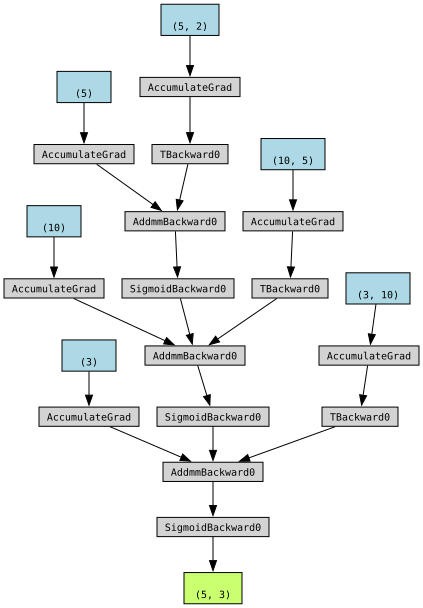

In [36]:
# Sequential을 이용하여 위 코드 재설계

class MyModel2(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Sequential(nn.Linear(2,5),
                                    nn.Sigmoid(),
                                    nn.Linear(5,10),
                                    nn.Sigmoid(),
                                    nn.Linear(10,3),
                                    nn.Sigmoid())

    def forward(self, x):
        x = self.linear(x)
        return x

model2 = MyModel2()
x = torch.randn(5,2)
y = model2(x) # model.forward(x)와 동일 (nn.Module의 __call__이라는 스페셜모듈 이요해서 forward 통과시킴)
print(y)

make_dot(y)

In [38]:
# 인덱싱을 통해 볼수도있다
print(model2)
print(model2.linear[0].weight)
print(model2.linear[-2].bias) # 마지막꺼에서 두번째 nn.Linear(10,3)의 bias를 보자 -1로해서 마지막꺼에서 보자하면 error(활성함수이기때문에 바이어스 안갖음)

MyModel2(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=5, out_features=10, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=10, out_features=3, bias=True)
    (5): Sigmoid()
  )
)
Parameter containing:
tensor([[ 0.3583, -0.3929],
        [ 0.1965, -0.6656],
        [-0.0474, -0.2291],
        [-0.1526, -0.1107],
        [-0.3015, -0.3142]], requires_grad=True)
Parameter containing:
tensor([-0.2430,  0.0318,  0.1711], requires_grad=True)


In [39]:
list(model.parameters()) # 모델에 있는 모든 파라미터들(웨이트,바이어스들)을 보여준다

[Parameter containing:
 tensor([[ 0.2335,  0.4578],
         [ 0.2711,  0.2186],
         [-0.1652, -0.5588],
         [ 0.4343, -0.0378],
         [ 0.0680, -0.7019]], requires_grad=True),
 Parameter containing:
 tensor([-0.5875,  0.4850,  0.3428,  0.6608,  0.6732], requires_grad=True),
 Parameter containing:
 tensor([[ 0.0367,  0.1413, -0.1170, -0.2176, -0.4076],
         [-0.1968, -0.0107,  0.4318, -0.1210, -0.1720],
         [-0.2428,  0.1936,  0.1564, -0.0778, -0.3660],
         [ 0.0651, -0.3770, -0.2436,  0.1266,  0.3175],
         [ 0.1076,  0.2082, -0.2188,  0.2969,  0.0836],
         [ 0.2440, -0.2568, -0.0476,  0.4089, -0.3449],
         [-0.1512, -0.3418, -0.0831, -0.1045, -0.2554],
         [ 0.3501, -0.1471, -0.4285, -0.3616, -0.3559],
         [-0.0960, -0.2508,  0.0624, -0.3762, -0.1787],
         [ 0.2803, -0.3165,  0.0509, -0.3354, -0.2454]], requires_grad=True),
 Parameter containing:
 tensor([ 0.1063,  0.2837,  0.2924,  0.0880,  0.2967,  0.1195,  0.4428, -0.3672,
  

In [40]:
# 파라미터 수 구하기

num = sum([p.numel() for p in model.parameters() if p.requires_grad]) # numel = number of element
print(num)

"""
transfer learning할때 일부 requires_grad를 False로 바꿀때도 이용가능
"""

108
